In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df=pd.read_excel("../data/raw/Online Retail.xlsx")

In [2]:
display(df.head(5),df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


None

In [3]:
display(df.isna().sum(), df['Country'].value_counts())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [4]:
df['CustomerID'] = df['CustomerID'].fillna('Unknown').astype(str)
df['Description'] = df['Description'].fillna('No description')
df['InvoiceTime'] = df['InvoiceDate'].dt.time
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'].dt.date)

df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['total_price'] = df_clean['UnitPrice'] * df_clean['Quantity']
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

df_clean["log_Quantity"] = np.log1p(df_clean["Quantity"])
df_clean["log_total_price"] = np.log1p(df_clean["total_price"])
df_clean["log_UnitPrice"] = np.log1p(df_clean["UnitPrice"])
df_clean['Quarters']= df_clean['InvoiceDate'].dt.to_period("Q")





In [5]:
numeric_cols = ['Quantity','UnitPrice','total_price',"log_Quantity","log_total_price","log_UnitPrice"]

desc = df_clean[numeric_cols].describe().T
desc['variance'] = df_clean[numeric_cols].var()
desc['skewness'] = df_clean[numeric_cols].skew()
desc['kurtosis'] = df_clean[numeric_cols].kurtosis()
desc['cv'] = desc['std']/desc['mean']
display(desc.round(3))

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,cv
Quantity,530104.0,10.542,155.524,1.000,1.000,3.000,10.000,80995.000,24187.753,471.728,236462.343,14.753
UnitPrice,530104.0,3.908,35.916,0.001,1.250,2.080,4.130,13541.330,1289.936,206.088,62483.143,9.191
total_price,530104.0,20.122,270.357,0.001,3.750,9.900,17.700,168469.600,73092.769,506.706,297651.661,13.436
log_Quantity,530104.0,1.710,0.989,0.693,0.693,1.386,2.398,11.302,0.979,1.025,1.077,0.578
log_total_price,530104.0,2.331,1.019,0.001,1.558,2.389,2.929,12.035,1.039,0.561,0.945,0.437
log_UnitPrice,530104.0,1.240,0.644,0.001,0.811,1.125,1.635,9.514,0.415,1.111,3.643,0.519


In [6]:
print("\n TOTAL PRICE BY COUNTRY SUMMARY STATISTTICS")
display(df_clean.groupby('Country')['total_price']
    .agg(['sum','mean','median','min','max','std'])
    .round(2)
    .sort_values(by='sum', ascending= False))

print("\n TOTAL PRICE BY QUATERS")
display(df_clean.groupby('Quarters')['total_price']
       .agg(['sum','mean','median','min','max','std'])
       .round(2)
       .sort_values(by='Quarters', ascending= False))
print("\n TOTAL TRANSACTION AMOUNT")
print(df_clean['total_price'].sum())


 TOTAL PRICE BY COUNTRY SUMMARY STATISTTICS


,sum,mean,median,min,max,std
Country,,,,,,
United Kingdom,9025222.08,18.60,8.42,0.00,168469.60,281.28
Netherlands,285446.34,121.00,91.80,0.39,4992.00,164.05
EIRE,283453.96,35.93,17.40,0.42,2365.20,84.60
Germany,228867.14,25.32,17.00,0.39,876.00,35.46
France,209715.11,24.95,16.60,0.29,4161.06,74.09
Australia,138521.31,117.19,66.00,0.42,1718.40,159.90
Spain,61577.11,24.79,15.00,0.21,1350.00,70.35
Switzerland,57089.90,29.04,17.70,0.42,360.00,35.24
Belgium,41196.34,20.28,16.60,2.50,165.00,15.25



 TOTAL PRICE BY QUATERS


,sum,mean,median,min,max,std
Quarters,,,,,,
2011Q4,3303268.31,19.69,8.50,0.06,168469.60,417.13
2011Q3,2536949.74,20.73,10.20,0.00,11062.06,79.16
2011Q2,2070084.54,20.45,10.20,0.00,38970.00,141.48
2011Q1,1932635.81,19.88,9.90,0.18,77183.60,255.92
2010Q4,823746.14,19.86,8.47,0.14,13541.33,97.35


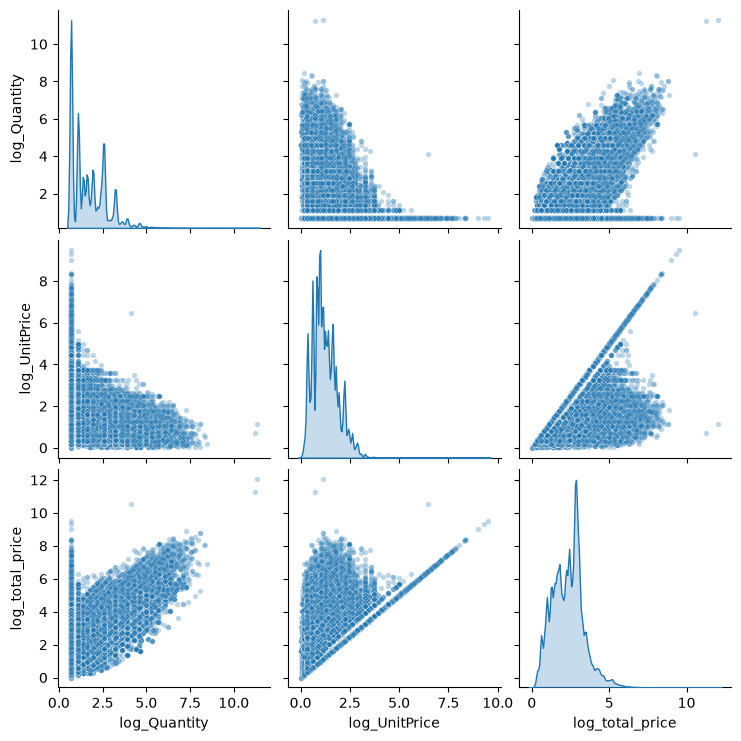

In [7]:
sns.pairplot(
    df_clean[["log_Quantity", "log_UnitPrice", "log_total_price"]],
    kind="scatter",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 15},  # Alpha transparency helps reduce overplotting
)
plt.show()

--- TOP 10 ITEMS BY TOTAL QUANTITY SOLD ---


,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
3,JUMBO BAG RED RETROSPOT,48474
4,WHITE HANGING HEART T-LIGHT HOLDER,37891
5,POPCORN HOLDER,36761
6,ASSORTED COLOUR BIRD ORNAMENT,36461
7,PACK OF 72 RETROSPOT CAKE CASES,36419
8,RABBIT NIGHT LIGHT,30788
9,MINI PAINT SET VINTAGE,26633



--- TOP 10 ITEMS BY PURCHASE FREQUENCY ---


,Description,Frequency
0,WHITE HANGING HEART T-LIGHT HOLDER,2323
1,JUMBO BAG RED RETROSPOT,2112
2,REGENCY CAKESTAND 3 TIER,2017
3,PARTY BUNTING,1706
4,LUNCH BAG RED RETROSPOT,1594
5,ASSORTED COLOUR BIRD ORNAMENT,1489
6,SET OF 3 CAKE TINS PANTRY DESIGN,1399
7,PACK OF 72 RETROSPOT CAKE CASES,1370
8,LUNCH BAG BLACK SKULL.,1328
9,NATURAL SLATE HEART CHALKBOARD,1263


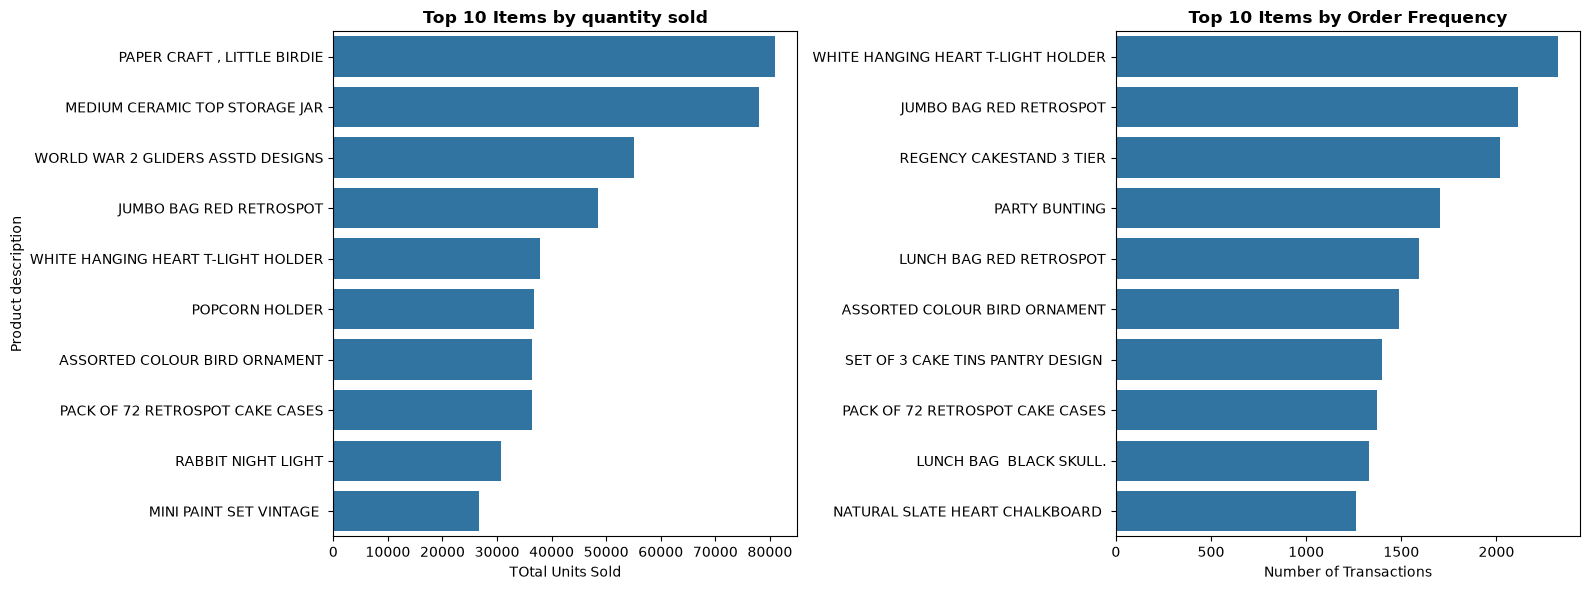

In [22]:
# 1. Most common item by TOTAL QUANTITY SOLD
most_bought_by_qty = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Most common item by PURCHASE FREQUENCY (Number of orders/rows)
most_bought_by_freq = (
    df_clean["Description"]
    .value_counts()
    .reset_index()
    .rename(columns={"count": "Frequency"})
)

print("--- TOP 10 ITEMS BY TOTAL QUANTITY SOLD ---")
display(most_bought_by_qty.head(10))

print("\n--- TOP 10 ITEMS BY PURCHASE FREQUENCY ---")
display(most_bought_by_freq.head(10))



fig, axes = plt.subplots(1,2, figsize=(16,6))
ax1,ax2 = axes.flatten()

sns.barplot(data=most_bought_by_qty.head(10), x="Quantity", y='Description', ax=ax1)
ax1.set_title("Top 10 Items by quantity sold", fontsize=12, fontweight='bold')
ax1.set_xlabel("TOtal Units Sold")
ax1.set_ylabel('Product description')

sns.barplot(
    data=most_bought_by_freq.head(10),
    x="Frequency",
    y="Description",
    ax=ax2
)
ax2.set_title("Top 10 Items by Order Frequency", fontsize=12, fontweight='bold')
ax2.set_xlabel("Number of Transactions")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

In [29]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date-x.max()).days,
    'InvoiceNo': 'nunique',
    'total_price':'sum'
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

#Recency -> Lower is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
#Frequency
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
#Monetary -> Higher is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])


#Combined RFM Score string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Define Customer Segments based on R and F scores
def segment_customer(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    m = int(df['M_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Promising / Recent'
    elif r <= 2 and f >= 3:
        return 'At Risk / Need Attention'
    else:
        return 'Hibernating / Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Segment Summary Table
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

total_rev = rfm['Monetary'].sum()
total_cust = rfm['CustomerID'].count()

segment_summary['Customer_Pct'] = (segment_summary['Customer_Count'] / total_cust) * 100
segment_summary['Revenue_Pct'] = (segment_summary['Total_Revenue'] / total_rev) * 100
segment_summary = segment_summary.sort_values(by='Total_Revenue', ascending=False)

print("=== RFM Segment Summary ===")
print(segment_summary.to_string(index=False))

# 3. Pareto Principle (80/20 Rule) Analysis
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False).reset_index(drop=True)
rfm_sorted['Cum_Revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['Cum_Rev_Pct'] = (rfm_sorted['Cum_Revenue'] / total_rev) * 100
rfm_sorted['Cum_Cust_Pct'] = ((rfm_sorted.index + 1) / total_cust) * 100

# Top 20% Customers Revenue Contribution
top_20_pct_idx = int(np.ceil(0.20 * total_cust))
top_20_rev_pct = rfm_sorted.loc[top_20_pct_idx - 1, 'Cum_Rev_Pct']

# How many top customers account for 80% of total revenue?
cust_for_80_rev = rfm_sorted[rfm_sorted['Cum_Rev_Pct'] >= 80].index[0] + 1
cust_pct_for_80_rev = (cust_for_80_rev / total_cust) * 100

print("\n=== Pareto Analysis Results ===")
print(f"Total Unique Customers: {total_cust}")
print(f"Total Revenue: ${total_rev:,.2f}")
print(f"Top 20% Customers ({top_20_pct_idx} customers) generate: {top_20_rev_pct:.2f}% of total revenue")
print(f"Top {cust_pct_for_80_rev:.2f}% of customers ({cust_for_80_rev} customers) account for 80.0% of total revenue")

=== RFM Segment Summary ===
                 Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Customer_Pct  Revenue_Pct
               Champions            1129    13.607617      11.283437   6769.482153    7642745.351     26.019820    71.650618
         Loyal Customers             818    37.997555       3.677262   1683.134829    1376804.290     18.852270    12.907519
At Risk / Need Attention             656   151.786585       3.405488   1248.913492     819287.251     15.118691     7.680805
      Hibernating / Lost            1071   217.605042       1.101774    488.643307     523336.982     24.683107     4.906276
      Promising / Recent             665    37.024060       1.201504    457.910782     304510.670     15.326112     2.854783

=== Pareto Analysis Results ===
Total Unique Customers: 4339
Total Revenue: $10,666,684.54
Top 20% Customers (868 customers) generate: 78.77% of total revenue
Top 21.53% of customers (934 customers) account for 80.0% of t

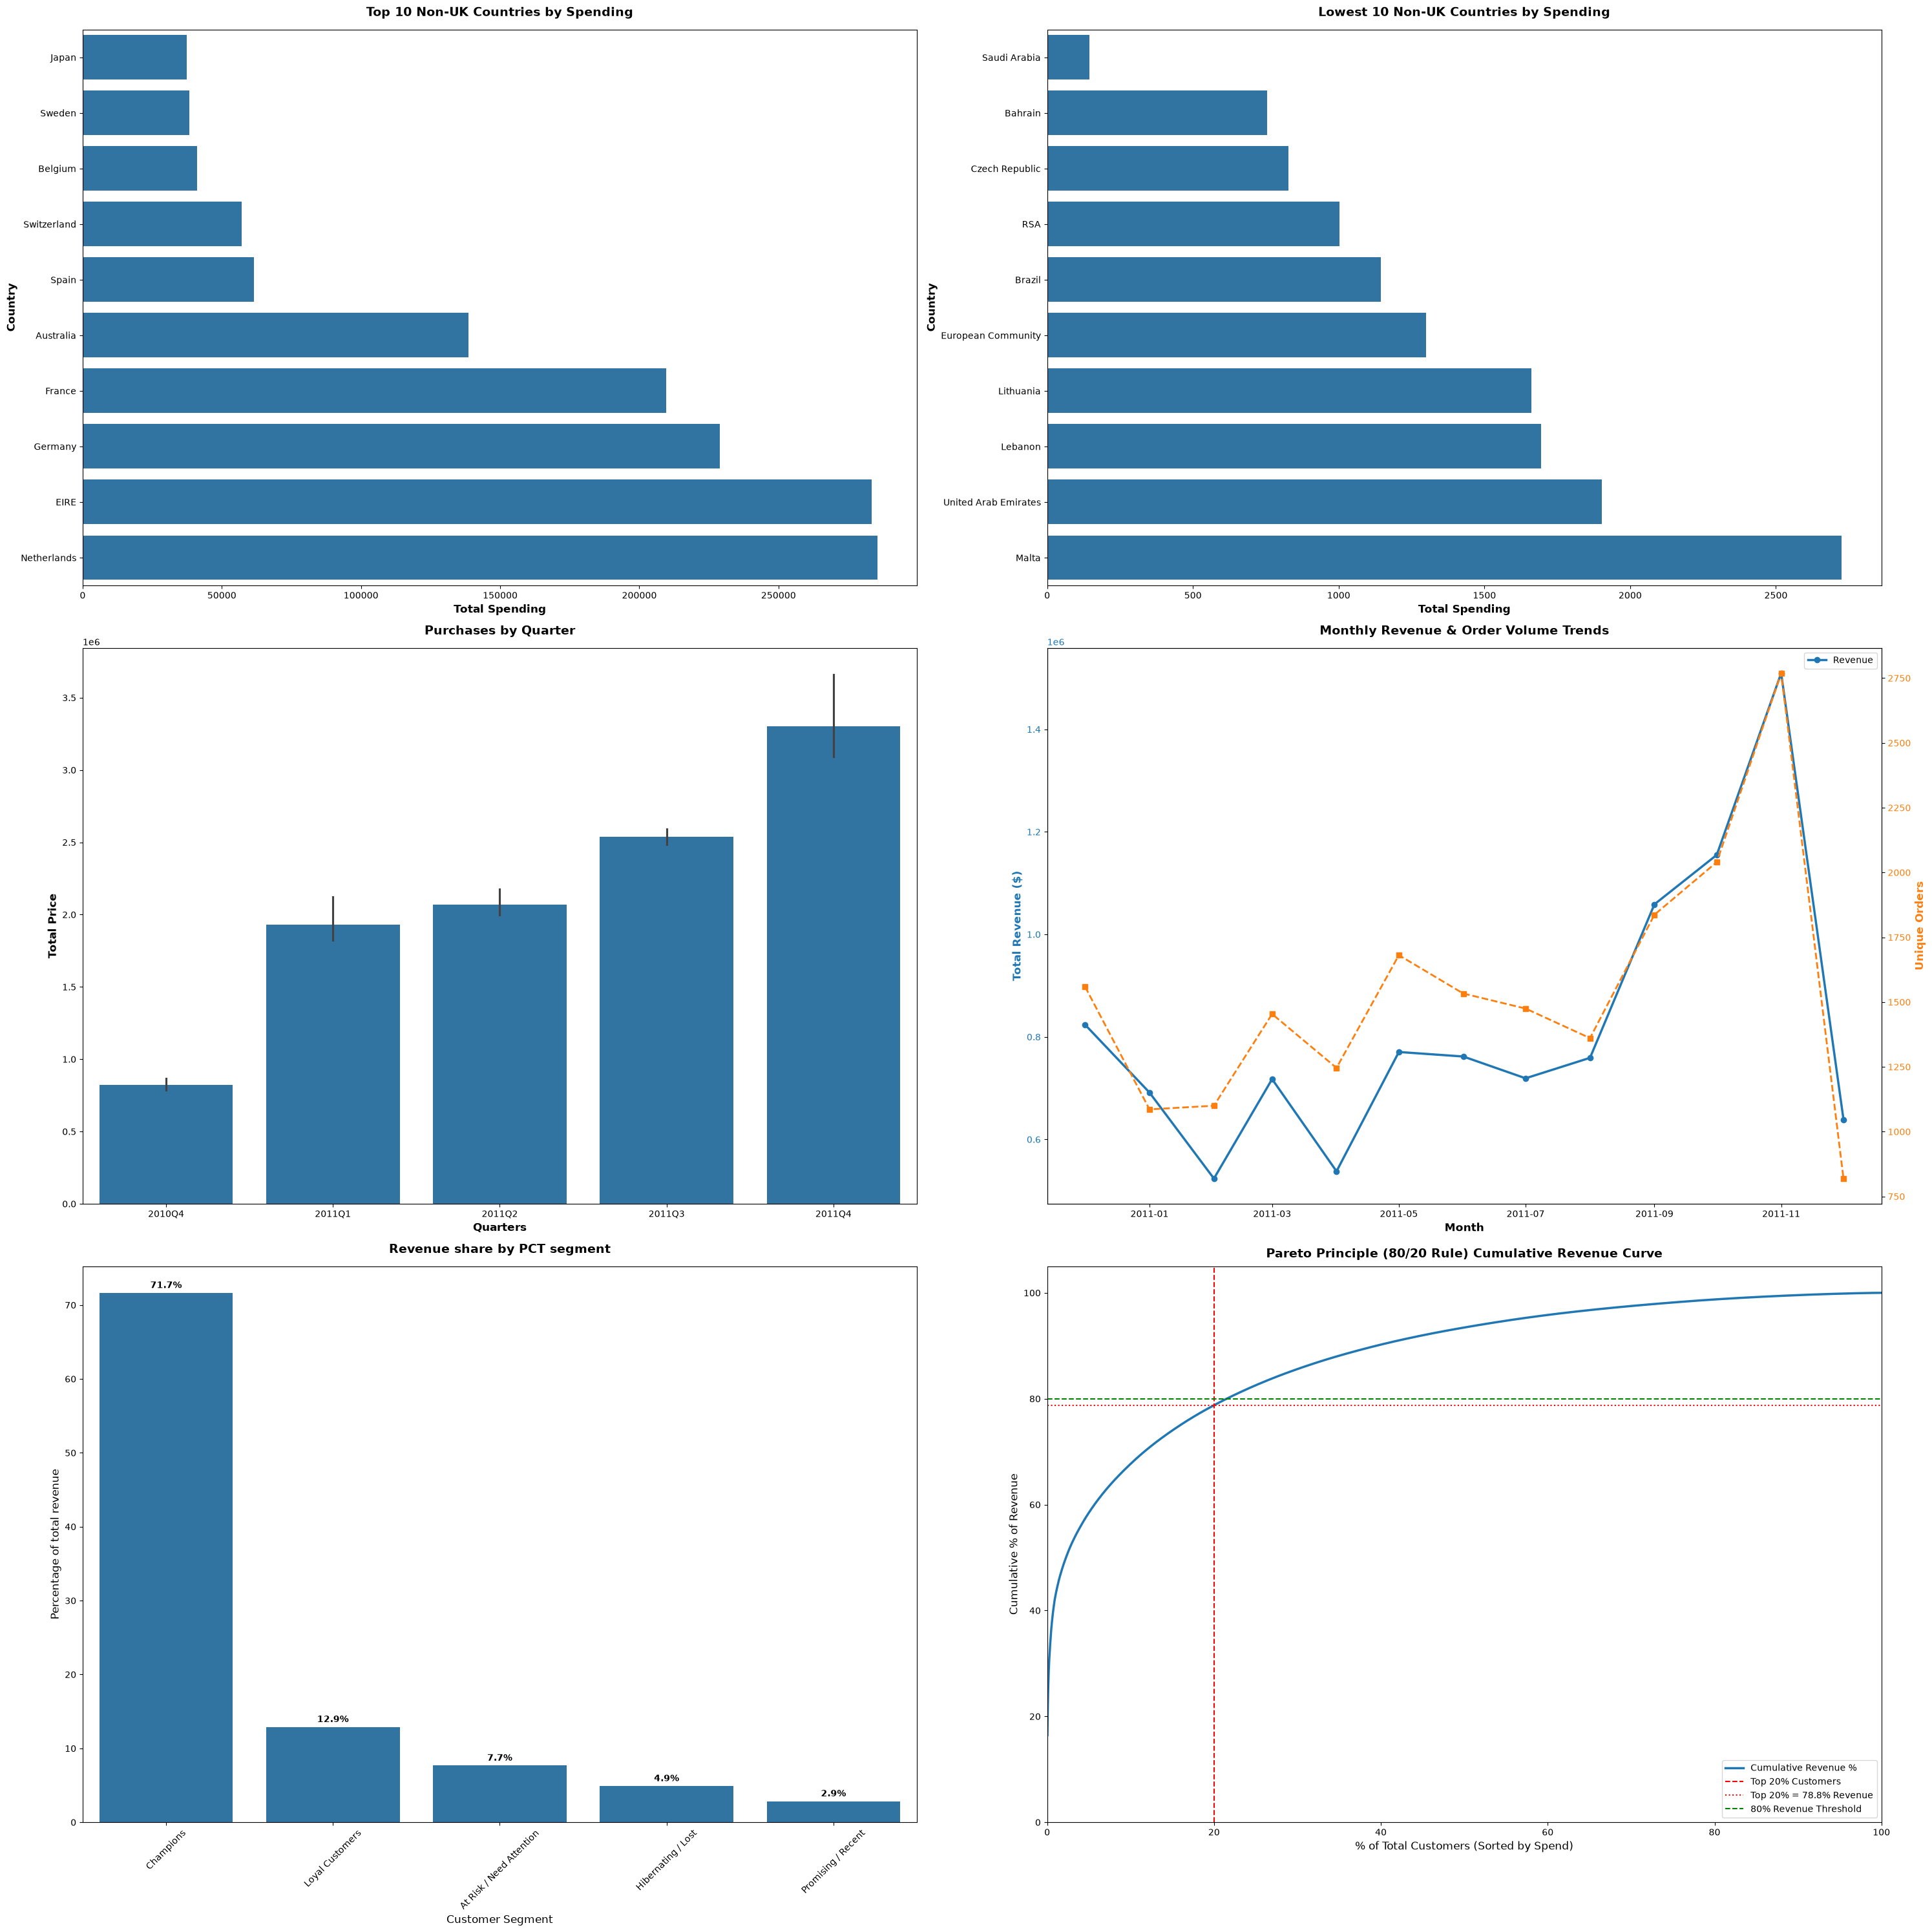

In [34]:
fig, axes = plt.subplots(3,2, figsize=(30,30))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()
def plot_country_spending(df, ax, n=10, ascending=False, log_scale=False):
    spend_df = (
        df[(df["Country"] != "United Kingdom")]
        .groupby("Country")["total_price"]
        .sum()
        .sort_values(ascending=ascending)
        .head(n)
        .reset_index()
    )

    spend_df = spend_df.sort_values(by="total_price", ascending=True)

    spend_df["Country"] = spend_df["Country"].astype(str)
    
    sns.barplot(data=spend_df, x="total_price", y="Country",ax=ax)

    label_type = "Lowest" if ascending else "Top"
    ax.set_title(f"{label_type} {n} Non-UK Countries by Spending", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Total Spending",fontsize=12, fontweight='bold')
    ax.set_ylabel("Country",fontsize=12, fontweight='bold')
    #ax.tick_params(axis="x", rotation=90)

    if log_scale:
        ax.set_xscale("log")

    return ax
plot_country_spending(df_clean,ax1)
plot_country_spending(df_clean,ax2, ascending=True)


sns.barplot(
    data=df_clean,
    x='Quarters',
    y='total_price',
    estimator= np.sum,
    ax=ax3
)
ax3.set_title("Purchases by Quarter", fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Quarters",fontsize=12, fontweight='bold')
ax3.set_ylabel("Total Price",fontsize=12, fontweight='bold')



color1='#1f77b4'
color2='#ff7f0e'

monthly_data = df_clean.groupby('YearMonth').agg(
    TotalRevenue=('total_price', 'sum'),
    OrderCount=('InvoiceNo', 'nunique')
).reset_index()

monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()
ax4.set_xlabel('Month', fontsize=12, fontweight='bold')
ax4.set_ylabel('Total Revenue ($)', color=color1, fontsize=12, fontweight='bold')
ax4.plot(monthly_data['YearMonth'], monthly_data['TotalRevenue'], 
         color=color1, marker='o', linewidth=2.5, label='Revenue')
ax4.tick_params(axis='y', labelcolor=color1)


# Dual Axis for Order Count (Line 2)
ax4_twin = ax4.twinx()  
ax4_twin.set_ylabel('Unique Orders', color=color2, fontsize=12, fontweight='bold')
ax4_twin.plot(monthly_data['YearMonth'], monthly_data['OrderCount'], 
              color=color2, marker='s', linestyle='--', linewidth=2, label='Orders')
ax4_twin.tick_params(axis='y', labelcolor=color2)

ax4.set_title('Monthly Revenue & Order Volume Trends', fontsize=14, fontweight='bold', pad=15)
ax4.legend()

sns.barplot(data=segment_summary,
           x='Segment',
           y='Revenue_Pct',
           ax=ax5)
ax5.set_title('Revenue share by PCT segment', fontsize=14,pad=15, fontweight='bold')
ax5.set_xlabel('Customer Segment', fontsize=12)
ax5.set_ylabel('Percentage of total revenue', fontsize=12)
ax5.tick_params(axis='x', labelrotation=45)
ax5.bar_label(ax5.containers[0], fmt='%.1f%%', padding=3, fontweight='bold')


ax6.plot(rfm_sorted['Cum_Cust_Pct'], rfm_sorted['Cum_Rev_Pct'], color='#1f77b4', linewidth=2.5, label='Cumulative Revenue %')
ax6.axvline(x=20, color='red', linestyle='--', linewidth=1.5, label='Top 20% Customers')
ax6.axhline(y=top_20_rev_pct, color='red', linestyle=':', linewidth=1.5, label=f'Top 20% = {top_20_rev_pct:.1f}% Revenue')
ax6.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label=f'80% Revenue Threshold')

ax6.set_title('Pareto Principle (80/20 Rule) Cumulative Revenue Curve', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('% of Total Customers (Sorted by Spend)', fontsize=12)
ax6.set_ylabel('Cumulative % of Revenue', fontsize=12)
ax6.set_xlim(0, 100)
ax6.set_ylim(0, 105)
ax6.legend(loc='lower right', frameon=True)




plt.tight_layout()
plt.show()